In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
from sklearn.preprocessing import LabelEncoder


In [2]:
all_city_cars_df=pd.read_csv(r"E:\GUVI Projects\Cardehko\all_car_details.csv")
all_city_cars_df.head()

all_city_cars_df.drop('Unnamed: 0', axis=1, inplace=True)

In [3]:
all_city_cars_df

,Color,Year of car manufacture,Length,price,Width,Brand Name,Transmission type,Seats,Body type,city,Car model,kilometer driven,Insurance Validity_value,Fuel type,Number of previous owners,Engine Displacement_value(cc)
0,Black,2022,3995mm,1150000.0,1790,Kia,Automatic,5.0,SUV,chennai,Kia Sonet,20000,Third Party insurance,Petrol,1,998
1,Grey,2015,3675mm,415000.0,1475mm,Maruti,Manual,7.0,Minivans,chennai,Maruti Eeco,20687,Comprehensive,Petrol,1,1196
2,Others,2021,3994mm,750000.0,1758,Nissan,Manual,5.0,SUV,chennai,Nissan Magnite,30000,Third Party insurance,Petrol,1,999
3,Silver,2015,3585mm,398000.0,1595mm,Hyundai,Manual,5.0,Hatchback,chennai,Hyundai i10,59247,Comprehensive,Petrol,1,1086
4,Others,2015,3955mm,550000.0,1694mm,Honda,Manual,5.0,Hatchback,chennai,Honda Jazz,50000,Third Party insurance,Petrol,1,1199
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8278,Others,2022,3695mm,510000.0,1655,Maruti,Manual,5.0,Hatchback,Kolkata,Maruti Celerio,10000,Third Party insurance,Petrol,1,998
8279,Others,2014,3395mm,180000.0,1490mm,Maruti,Manual,5.0,Hatchback,Kolkata,Maruti Alto 800,120000,Third Party insurance,Petrol,1,796
8280,Others,2011,4591mm,550000.0,1770mm,Mercedes-Benz,Automatic,5.0,Sedan,Kolkata,Mercedes-Benz C-Class,50000,Third Party insurance,Petrol,3,1796
8281,Others,2012,3775mm,140000.0,1680mm,Maruti,Manual,5.0,Hatchback,Kolkata,Maruti Ritz,40000,Third Party insurance,Petrol,1,1197


In [4]:
all_city_cars_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8283 entries, 0 to 8282
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Color                          8283 non-null   object 
 1   Year of car manufacture        8283 non-null   int64  
 2   Length                         8283 non-null   object 
 3   price                          8283 non-null   float64
 4   Width                          8283 non-null   object 
 5   Brand Name                     8283 non-null   object 
 6   Transmission type              8283 non-null   object 
 7   Seats                          8283 non-null   float64
 8   Body type                      8283 non-null   object 
 9   city                           8283 non-null   object 
 10  Car model                      8283 non-null   object 
 11  kilometer driven               8283 non-null   int64  
 12  Insurance Validity_value       8283 non-null   o

In [5]:

all_city_cars_df.head()

,Color,Year of car manufacture,Length,price,Width,Brand Name,Transmission type,Seats,Body type,city,Car model,kilometer driven,Insurance Validity_value,Fuel type,Number of previous owners,Engine Displacement_value(cc)
0,Black,2022,3995mm,1150000.0,1790,Kia,Automatic,5.0,SUV,chennai,Kia Sonet,20000,Third Party insurance,Petrol,1,998
1,Grey,2015,3675mm,415000.0,1475mm,Maruti,Manual,7.0,Minivans,chennai,Maruti Eeco,20687,Comprehensive,Petrol,1,1196
2,Others,2021,3994mm,750000.0,1758,Nissan,Manual,5.0,SUV,chennai,Nissan Magnite,30000,Third Party insurance,Petrol,1,999
3,Silver,2015,3585mm,398000.0,1595mm,Hyundai,Manual,5.0,Hatchback,chennai,Hyundai i10,59247,Comprehensive,Petrol,1,1086
4,Others,2015,3955mm,550000.0,1694mm,Honda,Manual,5.0,Hatchback,chennai,Honda Jazz,50000,Third Party insurance,Petrol,1,1199


Encoding Categorical Variables

In [6]:
# Create a backup DataFrame for original categorical values
original_values_df = all_city_cars_df.select_dtypes(include=['object']).copy()

# Initialize a dictionary to store label encoders for each column
label_encoders = {}

# Loop through each categorical column
for col in all_city_cars_df.select_dtypes(include=['object']).columns:
    label_encoder = LabelEncoder()
    
    # Fill missing values with the mode (most frequent value)
    mode_value = all_city_cars_df[col].mode()[0]
    all_city_cars_df[col] = all_city_cars_df[col].fillna(mode_value)
    
    # Fit and transform the column using label encoding
    all_city_cars_df[col] = label_encoder.fit_transform(all_city_cars_df[col])
    
    # Store the label encoder for future use if needed
    label_encoders[col] = label_encoder

# Display the encoded DataFrame and original values
print(all_city_cars_df.head())
print(original_values_df.head())  # Original values saved here

   Color  Year of car manufacture  Length      price  Width  Brand Name  \
0      8                     2022     101  1150000.0    139          13   
1     57                     2015      39   415000.0     22          20   
2     86                     2021      98   750000.0    118          24   
3    116                     2015      26   398000.0     38           9   
4     86                     2015      82   550000.0     70           8   

   Transmission type  Seats  Body type  city  Car model  kilometer driven  \
0                  0    5.0          7     5        100             20000   
1                  1    7.0          5     5        145             20687   
2                  1    5.0          7     5        197             30000   
3                  1    5.0          2     5         82             59247   
4                  1    5.0          2     5         61             50000   

   Insurance Validity_value  Fuel type  Number of previous owners  \
0                

In [7]:
# Save the label encoders to a pickle file
with open('label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

In [8]:
all_city_cars_df.to_csv('final data.csv')

final_df=pd.read_csv(r"E:\GUVI Projects\Cardehko\final data.csv")
final_df.drop('Unnamed: 0',axis=1, inplace=True)

In [9]:
final_df.describe()

,Color,Year of car manufacture,Length,price,Width,Brand Name,Transmission type,Seats,Body type,city,Car model,kilometer driven,Insurance Validity_value,Fuel type,Number of previous owners,Engine Displacement_value(cc)
count,8283.000000,8283.000000,8283.000000,8.283000e+03,8283.000000,8283.000000,8283.000000,8283.000000,8283.000000,8283.000000,8283.000000,8.283000e+03,8283.000000,8283.000000,8283.000000,8283.000000
mean,88.586865,2016.477001,130.126283,9.304945e+05,104.543281,16.162381,0.727273,5.200652,4.965109,2.443921,128.077146,5.930105e+04,3.773271,2.992394,1.361825,1424.470361
std,41.929870,3.868279,92.690799,1.226529e+06,64.657558,8.521594,0.445389,0.657882,2.709133,1.736114,69.165507,7.432858e+04,1.456286,1.431378,0.642288,467.418778
min,0.000000,1985.000000,0.000000,2.016100e+04,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,72.000000
25%,57.000000,2014.000000,55.000000,3.990000e+05,57.000000,9.000000,0.000000,5.000000,2.000000,1.000000,72.000000,3.057200e+04,2.000000,1.000000,1.000000,1197.000000
50%,86.000000,2017.000000,101.000000,6.000000e+05,96.000000,17.000000,1.000000,5.000000,7.000000,2.000000,131.000000,5.400000e+04,5.000000,4.000000,1.000000,1248.000000
75%,116.000000,2019.000000,192.500000,9.420000e+05,135.000000,20.000000,1.000000,5.000000,8.000000,4.000000,163.000000,8.000000e+04,5.000000,4.000000,2.000000,1498.000000
max,152.000000,2023.000000,402.000000,2.600000e+07,307.000000,32.000000,1.000000,10.000000,9.000000,5.000000,278.000000,5.500000e+06,6.000000,4.000000,5.000000,5000.000000


In [10]:
final_df.columns

Index(['Color', 'Year of car manufacture', 'Length', 'price', 'Width',
       'Brand Name', 'Transmission type', 'Seats', 'Body type', 'city',
       'Car model', 'kilometer driven', 'Insurance Validity_value',
       'Fuel type', 'Number of previous owners',
       'Engine Displacement_value(cc)'],
      dtype='object')

Data Visualization

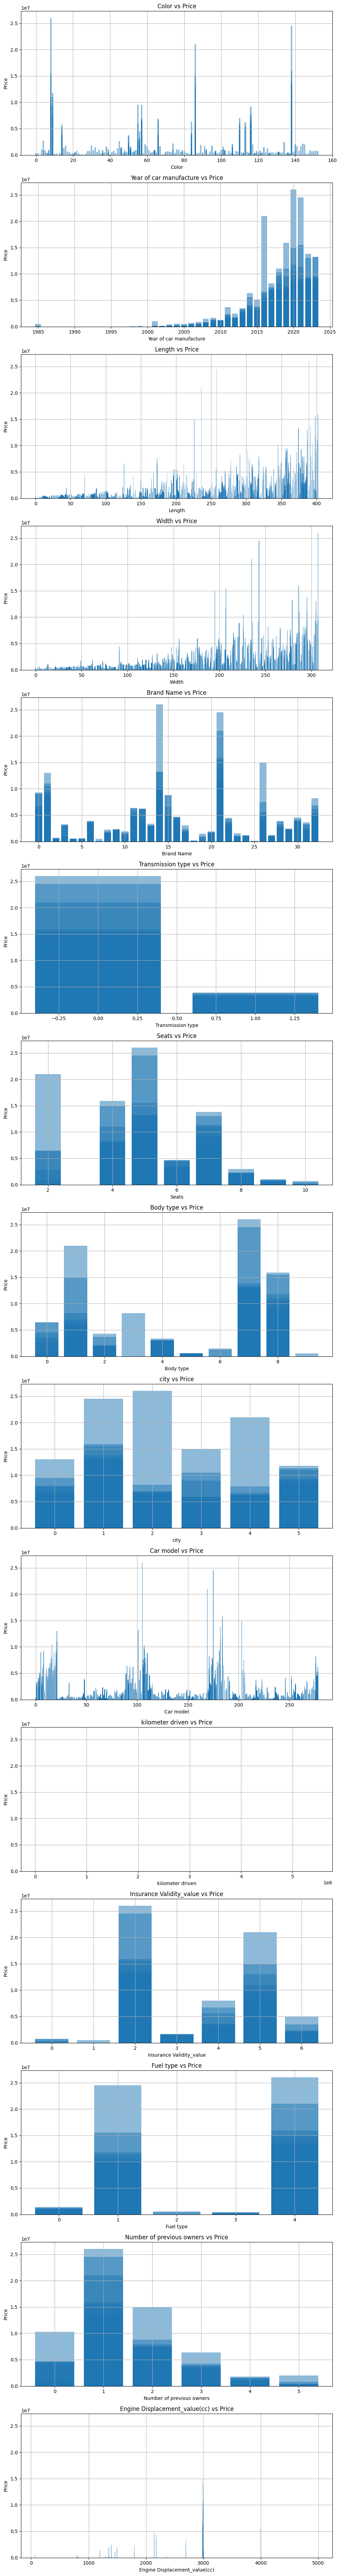

In [11]:
feature_columns = final_df.columns.drop('price')

# Create a figure with subplots
num_features = len(feature_columns)
fig, axes = plt.subplots(num_features, 1, figsize=(10, 5 * num_features))

# Loop through each feature and plot against 'price'
for ax, feature in zip(axes, feature_columns):
    ax.bar(final_df[feature], final_df['price'], alpha=0.5)
    ax.set_title(f'{feature} vs Price')
    ax.set_xlabel(feature)
    ax.set_ylabel('Price')
    ax.grid()

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

Feature Selection

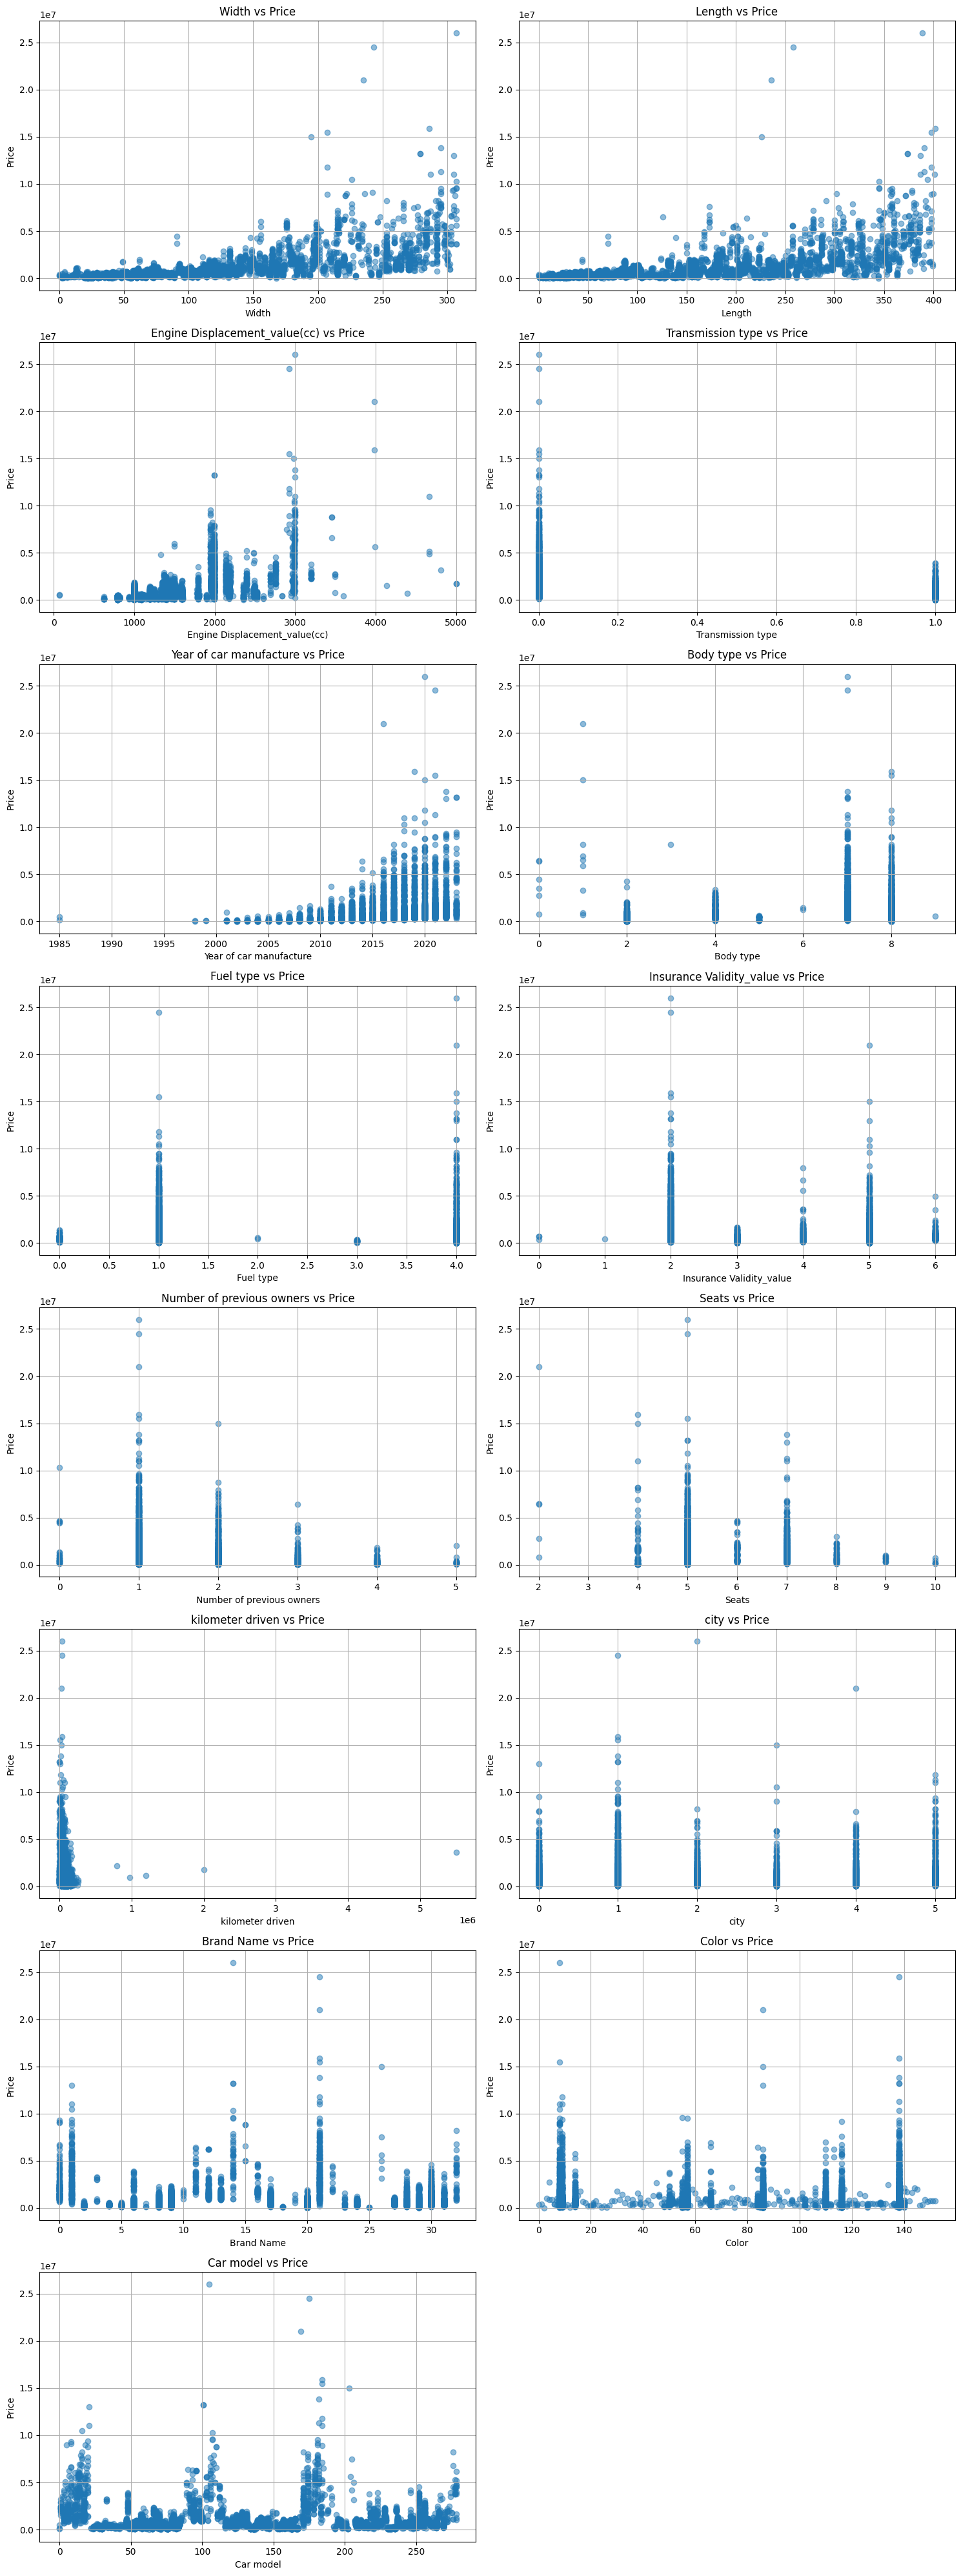

In [12]:
# Calculate the correlation matrix
correlation_matrix = final_df.corr()

# Get the absolute correlation values with respect to 'price' and sort them
correlation_with_price = correlation_matrix['price'].abs().sort_values(ascending=False)

# Select top features correlated with price (excluding 'price' itself)
feature_columns = correlation_with_price.index[1:22]

# Plot scatter plots for top features
num_features = len(feature_columns)
rows = (num_features // 2) + (num_features % 2)  # Calculate number of rows needed

plt.figure(figsize=(15, 5 * rows))
for i, feature in enumerate(feature_columns):
    plt.subplot(rows, 2, i + 1)  # Adjust layout based on the number of features
    plt.scatter(final_df[feature], final_df['price'], alpha=0.5)
    plt.title(f'{feature} vs Price')
    plt.xlabel(feature)
    plt.ylabel('Price')
    plt.grid()

plt.tight_layout()
plt.show()

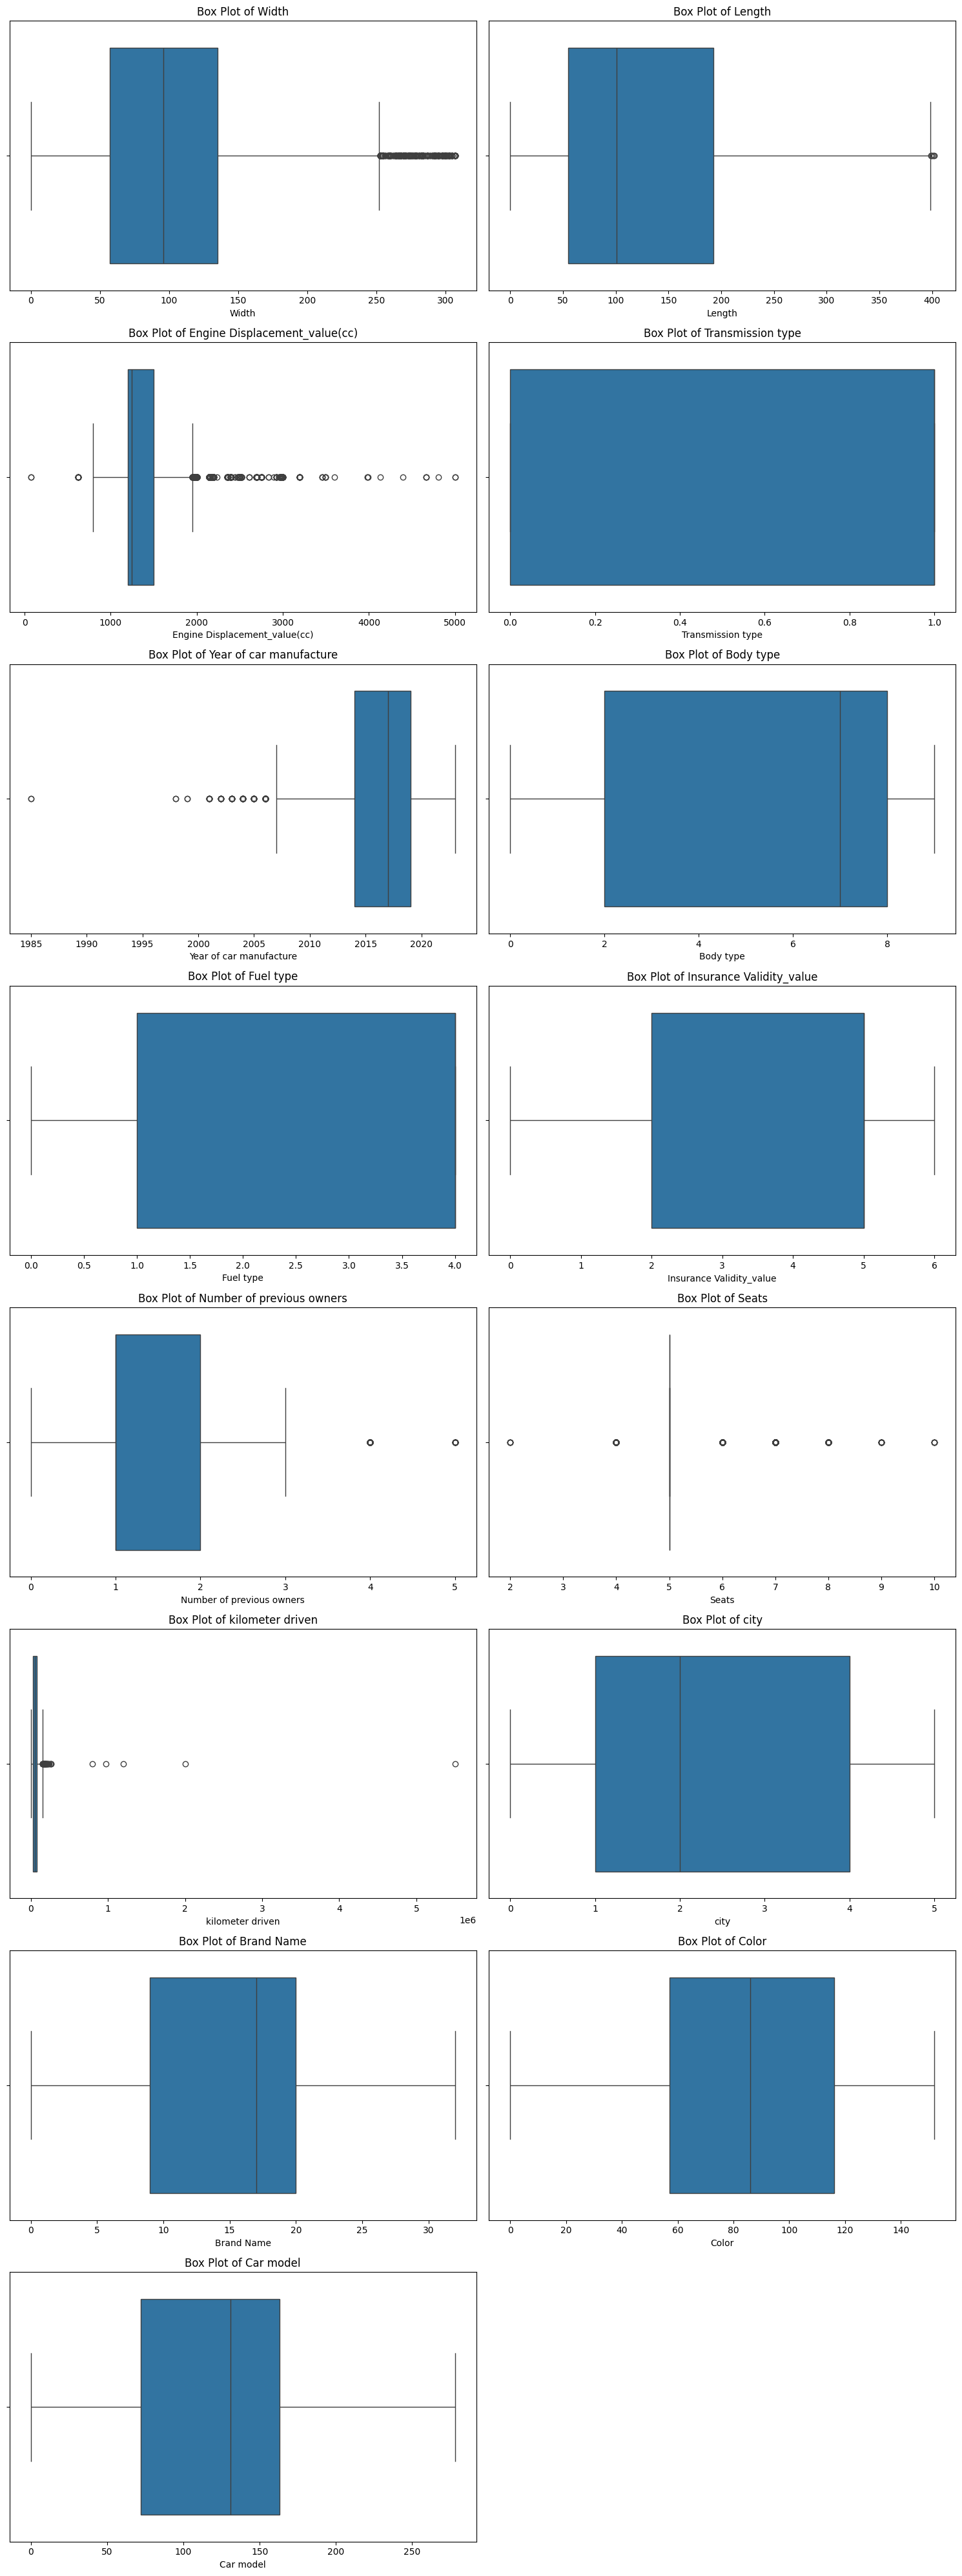

In [13]:
# 2. Box Plots for top features
plt.figure(figsize=(15, 5 * rows))
for i, feature in enumerate(feature_columns):
    plt.subplot(rows, 2, i + 1)
    sns.boxplot(x=final_df[feature])
    plt.title(f'Box Plot of {feature}')

plt.tight_layout()
plt.show()

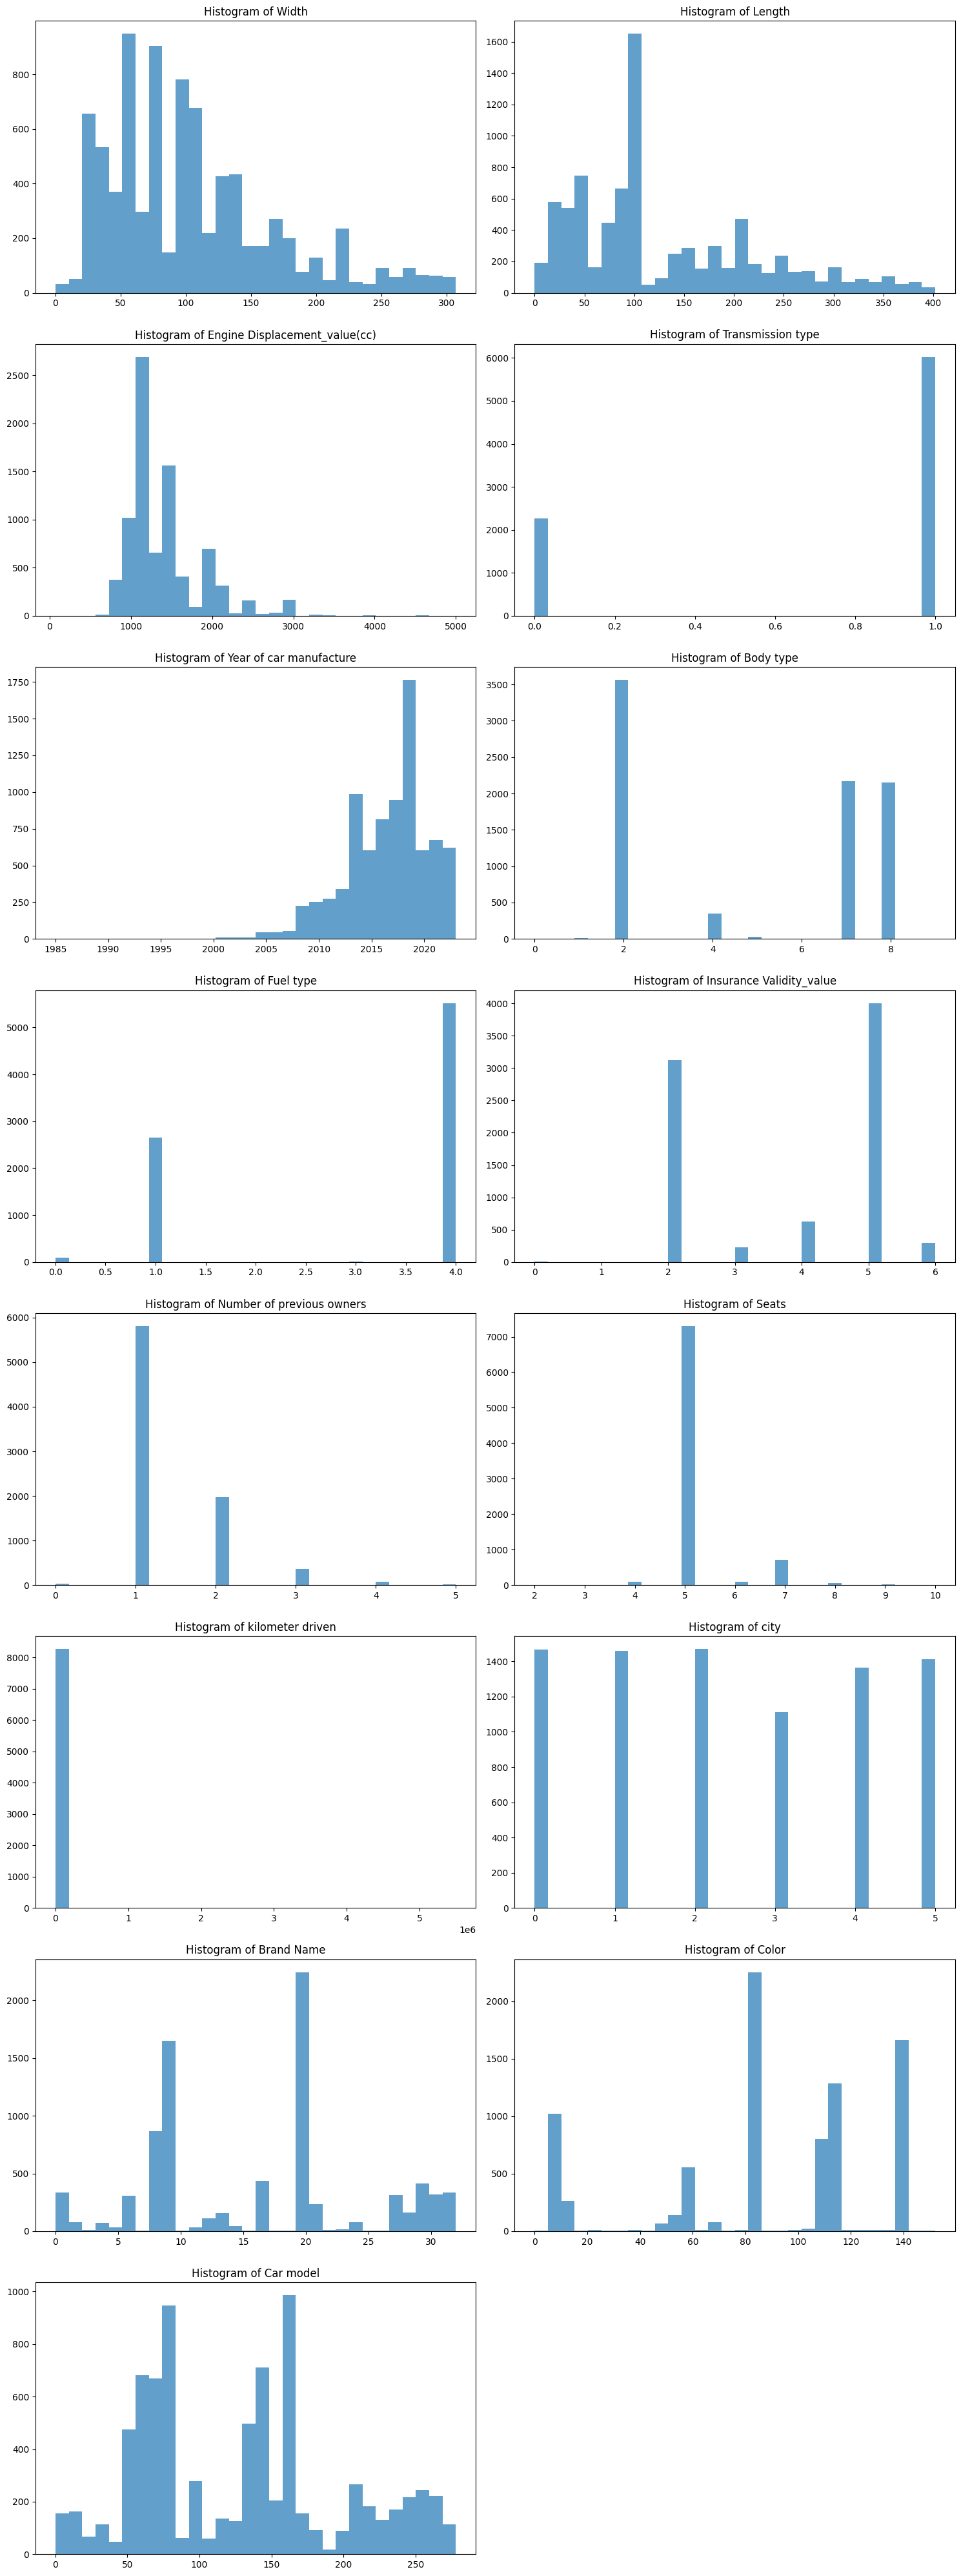

In [14]:
# 3. Histograms for top features
plt.figure(figsize=(15, 5 * rows))
for i, feature in enumerate(feature_columns):
    plt.subplot(rows, 2, i + 1)
    plt.hist(final_df[feature], bins=30, alpha=0.7)
    plt.title(f'Histogram of {feature}')

plt.tight_layout()
plt.show()

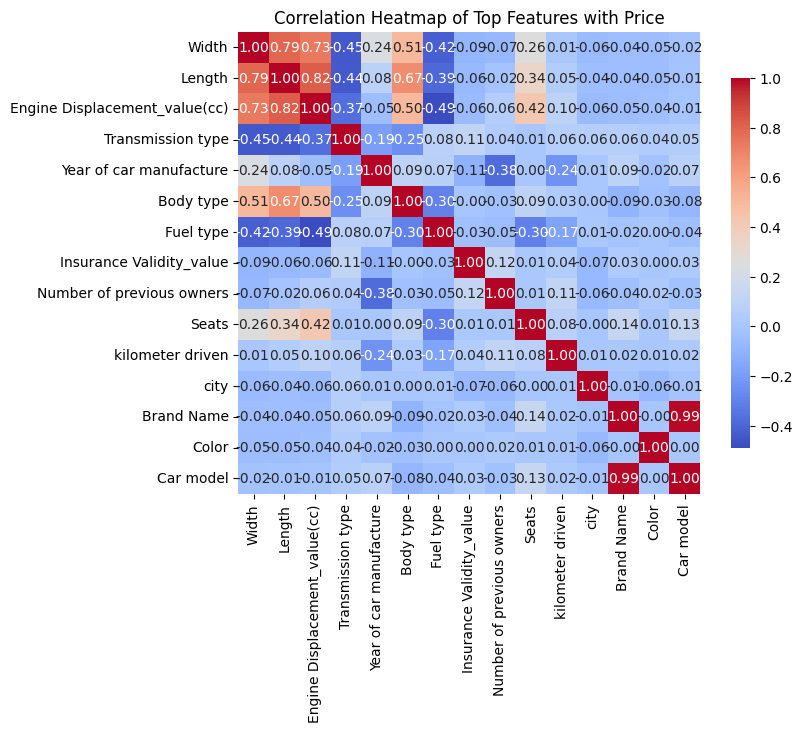

In [15]:
# 4. Correlation Heatmap for top features
plt.figure(figsize=(8, 6))
correlation_matrix = final_df[feature_columns].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Heatmap of Top Features with Price')
plt.show()


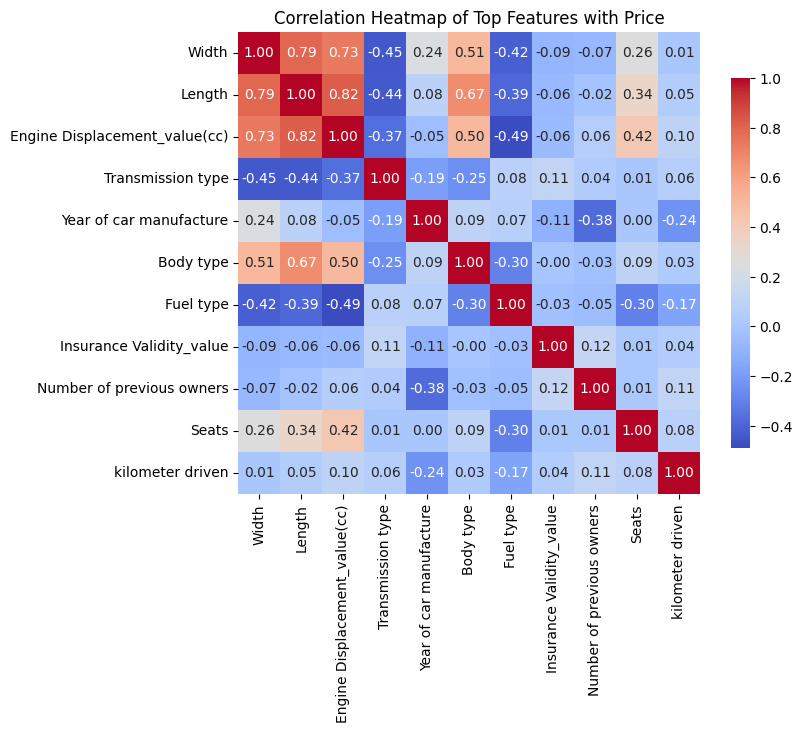

In [16]:
# Calculate the correlation matrix
correlation_matrix = final_df.corr()

# Get the absolute correlation values with respect to 'price' and sort them
correlation_with_price = correlation_matrix['price'].abs().sort_values(ascending=False)

# Select top 10 features correlated with price (excluding 'price' itself)
feature_columns = correlation_with_price.index[0:12]  # Selecting top 10 features, excluding 'price'

features = feature_columns[feature_columns != 'price'] 

num_features = len(features)
rows = (num_features // 2) + (num_features % 2)  # Calculate number of rows needed

plt.figure(figsize=(8, 6))
correlation_matrix = final_df[features].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Heatmap of Top Features with Price')
plt.show()

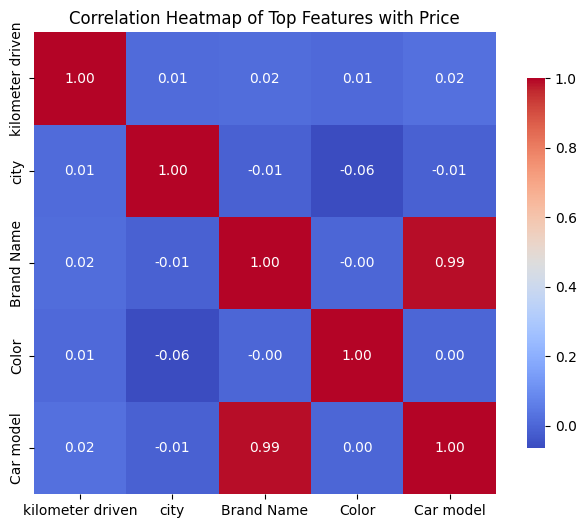

In [17]:
# 4. Correlation Heatmap for features

# Calculate the correlation matrix
correlation_matrix = final_df.corr()

# Get the absolute correlation values with respect to 'price' and sort them
correlation_with_price = correlation_matrix['price'].abs().sort_values(ascending=False)

# Select top 10 features correlated with price (excluding 'price' itself)
feature_columns = correlation_with_price.index[11:24]  # Selecting top 10 features, excluding 'price'

feature_columns = feature_columns[feature_columns != 'price'] 

num_features = len(feature_columns)
rows = (num_features // 2) + (num_features % 2)  # Calculate number of rows needed

plt.figure(figsize=(8, 6))
correlation_matrix = final_df[feature_columns].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Heatmap of Top Features with Price')
plt.show()